# 6 · ¿Más señal? Features agronómicas y satelitales

Si el clima mensual no ve la mitad de las anomalías (nb 5), ¿ayudan otras fuentes?
Probamos cuatro conjuntos de features, cada uno entrenando a la vista: **agronómicas**
(ventana crítica), **NDVI-AVHRR** (verdor, 1981+), **ERA5-Land** (suelo + heladas) y la
**combinación ERA5 + NDVI**.

Para cada conjunto evaluamos **cinco detectores** sobre el mismo `ds`:
- **VAE `recon_prob`**, **IForest** y **One-Class SVM (RBF)** sobre las features;
- **IForest** y **OCSVM** sobre el **espacio latente del VAE** (16 dim) entrenado con esas
  features — así vemos si comprimir con el VAE antes de un detector shallow ayuda cuando
  hay features extra.

In [1]:
import lab                      # utilidades: métricas y gráficos (experiments/lab.py)
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from src import config, data
from src.models import (IsolationForestDetector, OneClassSVMDetector,
                        AEDetector, DenoisingAEDetector, VAEDetector,
                        EnsembleDetector, DeepODDetector)
plt.rcParams["figure.dpi"] = 110
SEEDS = lab.SEEDS            # 10 semillas del estudio. Bajalas (p. ej. [42,43,44])
print("semillas:", SEEDS)   # para un Run all más rápido; los números se mueven ±std

semillas: [42, 43, 44, 45, 46, 47, 48, 49, 50, 51]


## 6.1 · La sonda: entrena los 5 detectores sobre un dataset (multi-seed)
Función a la vista. **Todo se evalúa con las mismas 5 semillas y se reporta media ± std**
— así la comparación entre conjuntos de features es en igualdad de condiciones, y una
diferencia dentro del ruido no se confunde con una mejora. Para cada semilla: entrena un
VAE (score directo), saca su latente con `.encode()`, y corre IForest/OCSVM sobre las
features **y** sobre ese latente.

> Usamos **5 semillas** (no 10) por costo: son 5 conjuntos × 5 detectores. Los números
> absolutos no son directamente comparables con el nb 3 (10 semillas), pero la comparación
> *interna* de este notebook es justa (mismo N para todos).

In [2]:
SEEDS_F = SEEDS[:5]                 # mismas semillas para TODAS las comparaciones de acá
def make_vae(seed):
    return VAEDetector(hidden_dims=(128,64), latent_dim=24, score_mode="recon_prob",
                       n_mc_samples=50, max_epochs=300, patience=30, random_state=seed)

def probe(dset):
    """media±std (5 semillas) de los 5 detectores sobre un dataset. Devuelve strings."""
    y = dset.y_test
    cols = {"VAE recon_prob":[], "IForest":[], "OCSVM-RBF":[],
            "IForest sobre latente VAE":[], "OCSVM sobre latente VAE":[]}
    for s in SEEDS_F:
        v = make_vae(s).fit(dset.X_train)
        Ztr, Zte = v.encode(dset.X_train), v.encode(dset.X_test)       # latente de ESTA semilla
        cols["VAE recon_prob"].append(lab.metrics(v.score_samples(dset.X_test), y)["pr_auc"])
        cols["IForest"].append(lab.metrics(IsolationForestDetector(n_estimators=200, max_features=0.3,
            random_state=s).fit(dset.X_train).score_samples(dset.X_test), y)["pr_auc"])
        cols["OCSVM-RBF"].append(lab.metrics(OneClassSVMDetector(kernel="rbf", nu=0.1)
            .fit(dset.X_train).score_samples(dset.X_test), y)["pr_auc"])
        cols["IForest sobre latente VAE"].append(lab.metrics(IsolationForestDetector(
            n_estimators=200, max_features=0.3, random_state=s).fit(Ztr).score_samples(Zte), y)["pr_auc"])
        cols["OCSVM sobre latente VAE"].append(lab.metrics(OneClassSVMDetector(kernel="rbf", nu=0.1)
            .fit(Ztr).score_samples(Zte), y)["pr_auc"])
    return {k: (float(np.mean(v)), float(np.std(v))) for k, v in cols.items()}  # (media, std)

## 6.2 · Los datasets: base + cada fuente + la combinación ERA5 + NDVI

In [3]:
panel_z    = data.prepare()
ds_base    = data.build_crop_dataset(panel_z, "soja")
ds_agro    = data.build_crop_dataset(panel_z, "soja", use_agro=True)

panel_ndvi = data.prepare(config.PANEL_NDVI_PATH, use_ndvi=True)
ds_ndvi    = data.build_crop_dataset(panel_ndvi, "soja", use_ndvi=True)

panel_era5 = data.prepare(config.PANEL_ERA5_PATH, use_era5=True)
ds_era5    = data.build_crop_dataset(panel_era5, "soja", use_era5=True)

# --- Combinación ERA5 + NDVI: pego las 4 columnas ERA5 al panel NDVI y activo ambos ---
er = data.load_panel(config.PANEL_ERA5_PATH, use_era5=True)
key = ["provincia","departamento","campania_inicio","cultivo"]
panel_combo  = panel_ndvi.merge(er[key + config.ERA5_COLS], on=key, how="left")
panel_combo  = data.compute_z_rinde(panel_combo)
ds_combo     = data.build_crop_dataset(panel_combo, "soja", use_ndvi=True, use_era5=True)

for nombre, d in [("base",ds_base),("agro",ds_agro),("NDVI",ds_ndvi),("ERA5",ds_era5),("ERA5+NDVI",ds_combo)]:
    print(f"{nombre:10s} {len(d.feature_cols):3d} features")

[data] dedup panel: 28683 → 21418 filas (7265 duplicados espurios por lat/lon eliminados)


[data] dedup panel: 28683 → 21418 filas (7265 duplicados espurios por lat/lon eliminados)


[data] dedup panel: 28683 → 21418 filas (7265 duplicados espurios por lat/lon eliminados)


[data] dedup panel: 28683 → 21418 filas (7265 duplicados espurios por lat/lon eliminados)


base        54 features
agro        58 features
NDVI        61 features
ERA5        58 features
ERA5+NDVI   65 features


## 6.3 · Resultados: 5 conjuntos de features × 5 detectores (PR-AUC test ± std, soja)

In [4]:
conjuntos = {"base": ds_base, "+ agro": ds_agro, "+ NDVI": ds_ndvi,
             "+ ERA5": ds_era5, "+ ERA5+NDVI": ds_combo}
res = {nombre: probe(d) for nombre, d in conjuntos.items()}
medias = pd.DataFrame({n: {k: m for k,(m,s) in r.items()} for n,r in res.items()}).T
stds   = pd.DataFrame({n: {k: s for k,(m,s) in r.items()} for n,r in res.items()}).T
# tabla legible: media±std
pd.DataFrame({n: {k: f"{m:.3f}±{s:.3f}" for k,(m,s) in r.items()} for n,r in res.items()}).T

,VAE recon_prob,IForest,OCSVM-RBF,IForest sobre latente VAE,OCSVM sobre latente VAE
base,0.591±0.027,0.526±0.019,0.477±0.000,0.425±0.043,0.494±0.060
+ agro,0.543±0.054,0.527±0.017,0.485±0.000,0.379±0.071,0.414±0.031
+ NDVI,0.581±0.039,0.518±0.019,0.488±0.000,0.438±0.123,0.455±0.059
+ ERA5,0.595±0.029,0.538±0.039,0.500±0.000,0.382±0.121,0.498±0.028
+ ERA5+NDVI,0.615±0.026,0.555±0.018,0.509±0.000,0.367±0.070,0.484±0.053


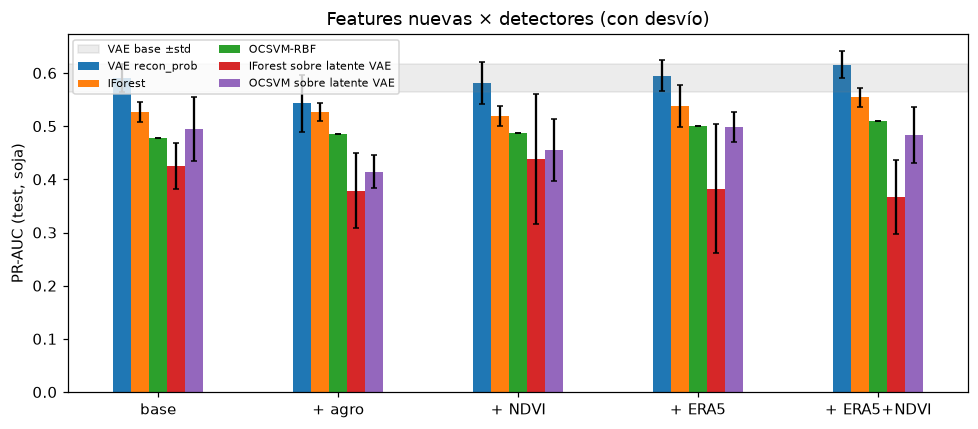

In [5]:
fig, ax = plt.subplots(figsize=(9,4))
medias.plot.bar(ax=ax, yerr=stds, capsize=2)      # barras CON su desvío
base_m, base_s = res["base"]["VAE recon_prob"]
ax.axhspan(base_m-base_s, base_m+base_s, color="gray", alpha=0.15, label="VAE base ±std")
ax.set_ylabel("PR-AUC (test, soja)"); ax.set_title("Features nuevas × detectores (con desvío)")
ax.legend(fontsize=7, ncol=2); plt.xticks(rotation=0); plt.tight_layout(); plt.show()

**Lectura (mirando las barras de error):**
- **`agro` y `NDVI` solos no ayudan** — su media queda igual o por debajo del base.
- **`ERA5+NDVI` muestra la media más alta en los 3 detectores** (VAE, IForest y OCSVM
  suben sobre el base en la tabla), consistente. Pero **con VAEs single el ±std se solapa** con el
  base → acá, aislado, no alcanza para afirmarlo. **La clave está en 6.4**: cuando el
  ensemble baja la varianza, esa señal chica se vuelve nítida.
- Los detectores **sobre el latente no mejoran** con features extra.

## 6.4 · La prueba justa: seed-ensemble base vs seed-ensemble + ERA5+NDVI
El nb 4 fijó el modelo final como el **seed-ensemble**. La pregunta correcta no es "¿features
ayudan a un VAE single?" sino **"¿ayudan al ENSEMBLE?"** — comparado en igualdad de
condiciones (ambos ×10, mismas réplicas). El ensemble baja fuerte el ±std (la celda de abajo lo muestra), así que una mejora chica
que en el single quedaba enterrada por el ruido, acá se puede ver:

In [6]:
def ens_scores(dset, base):
    miembros = [VAEDetector(hidden_dims=(128,64), latent_dim=24, score_mode="recon_prob",
                n_mc_samples=50, max_epochs=300, patience=30, random_state=base+i) for i in range(10)]
    return EnsembleDetector(miembros).fit(dset.X_train).score_samples(dset.X_test)

for nombre, dset in [("ensemble BASE (solo clima)", ds_base), ("ensemble + ERA5+NDVI", ds_combo)]:
    prs = [lab.metrics(ens_scores(dset, b), dset.y_test)["pr_auc"] for b in [42, 52, 62]]
    print(f"{nombre:28s} {np.mean(prs):.3f}±{np.std(prs):.3f}")

ensemble BASE (solo clima)   0.616±0.004


ensemble + ERA5+NDVI         0.640±0.003


**Resultado: `ERA5+NDVI` SÍ mejora al ensemble**, y ahora de forma **significativa** —
la diferencia (ver la celda de arriba) es varias veces el ±std, y los intervalos **no se solapan**. La señal
estaba siempre ahí; solo se ve cuando el ensemble quita el ruido entre semillas (por eso
importa reportar varianza — sin eso, este hallazgo quedaba invisible en el nb 6.3).

**⭐ Modelo final del Componente A: seed-ensemble ×10 del VAE `recon_prob` + ERA5+NDVI.**

**Conclusión matizada sobre el techo:**
- El **techo estructural existe** (rondamos ~0.6, no valores altos; la mayoría de las
  anomalías siguen sin firma observable, nb 5).
- Pero **NO es cierto que "ninguna feature ayuda"**: el estado de suelo + verdor
  (`ERA5+NDVI`) aportan una mejora **chica pero real**. `agro` y `NDVI`-solo no; hace falta
  la **combinación** de suelo (ERA5) y vegetación (NDVI).